# Model Prediction Viewer
Loads a trained `.keras` checkpoint and runs it on every image in `data/raw/`.  
Each image gets a 4-panel figure:  
**Original → Classical Label (Frangi) → CNN Prediction → Overlay**

In [71]:
# ── 1. CONFIGURATION — edit these two lines only ───────────────────────────
MODEL_NAME = 'resunetpp'      # 'unetpp' | 'attention_unet' | 'resunetpp'
THRESHOLD  = 0.499     # sigmoid cutoff for binary prediction
# ───────────────────────────────────────────────────────────────────────────

import os, sys, glob, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf

# Add project root to path
ROOT = os.path.abspath('')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import config
from dataset import load_tif_image, preprocess_image, get_image_paths
from model_builder import is_multi_output

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU         : {config.GPU_AVAILABLE}')
print(f'Model       : {MODEL_NAME}')
print(f'Image size  : {config.IMAGE_SIZE}')

TensorFlow  : 2.21.0
GPU         : False
Model       : resunetpp
Image size  : (256, 256)


In [72]:
# ── 2. LOAD MODEL ──────────────────────────────────────────────────────────
ckpt_name = config.MODEL_REGISTRY[MODEL_NAME]['checkpoint_name']
ckpt_path = os.path.join(config.CHECKPOINT_DIR, ckpt_name)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(
        f'Checkpoint not found: {ckpt_path}\n'
        f'Run: python train.py --model {MODEL_NAME}'
    )

model = tf.keras.models.load_model(ckpt_path, compile=False)
n_params = model.count_params()

print(f'Loaded   : {ckpt_path}')
print(f'Params   : {n_params:,}')
print(f'Inputs   : {model.input_shape}')
print(f'Outputs  : {model.output_shape}')

Loaded   : /home/harsh/CV_work/group_8/checkpoints/best_model_resunetpp.keras
Params   : 1,239,198
Inputs   : (None, 256, 256, 1)
Outputs  : (None, 256, 256, 1)


In [73]:
# ── 3. PREDICTION HELPER ───────────────────────────────────────────────────
def predict_single(img_resized):
    """
    Run one forward pass on a (H,W) float32 image.
    Returns (prob_map float32 H×W, binary_mask uint8 H×W, elapsed_sec).
    """
    tensor = img_resized[np.newaxis, ..., np.newaxis].astype(np.float32)
    t0 = time.time()
    outputs = model(tensor, training=False)
    elapsed = time.time() - t0

    # UNet++ returns a list (deep supervision); take the last/deepest head
    logits = outputs[-1] if isinstance(outputs, (list, tuple)) else outputs
    prob   = tf.sigmoid(logits).numpy().squeeze()       # (H, W)
    binary = (prob >= THRESHOLD).astype(np.uint8)       # {0, 1}
    return prob, binary, elapsed

Found 6 image(s) — running inference...



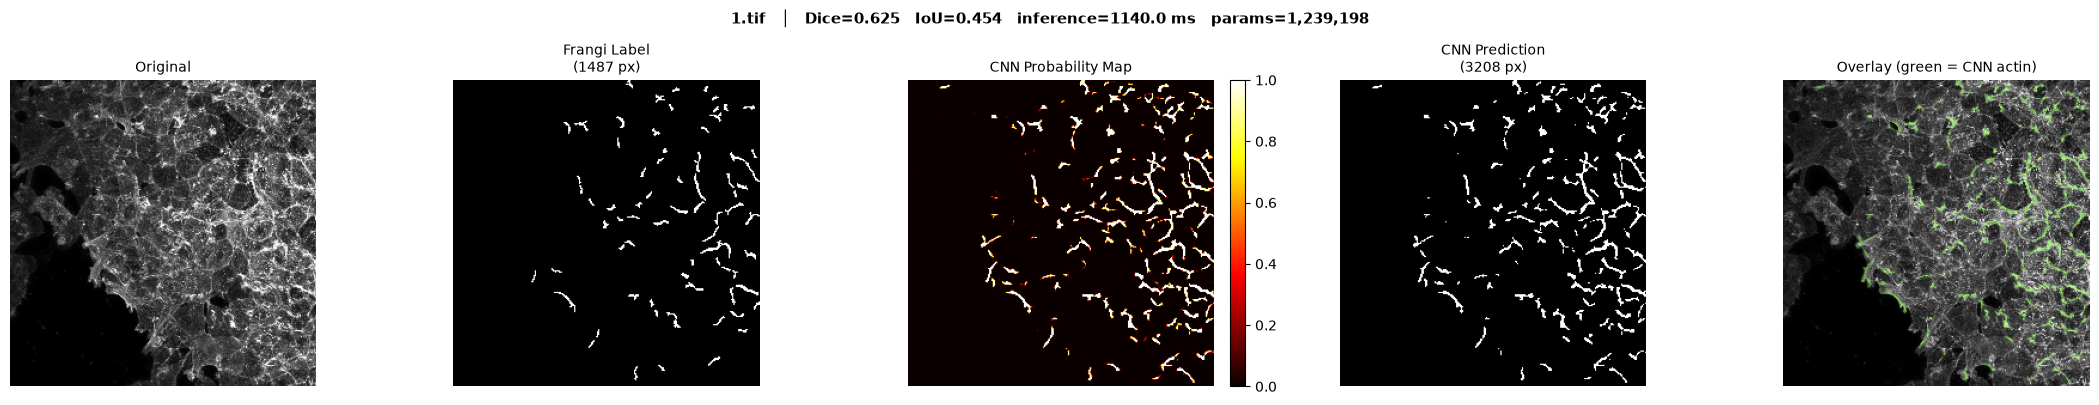

  1.tif  │  label=1487 px  pred=3208 px  Dice=0.625  IoU=0.454  1140.0 ms



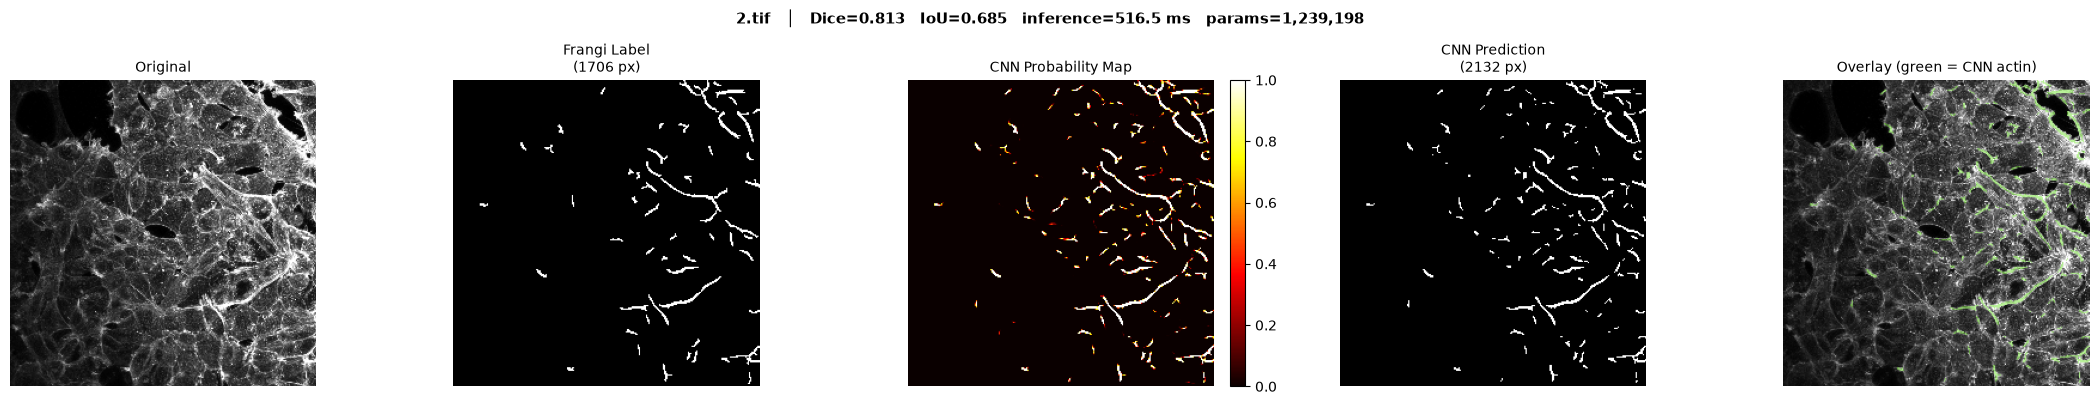

  2.tif  │  label=1706 px  pred=2132 px  Dice=0.813  IoU=0.685  516.5 ms



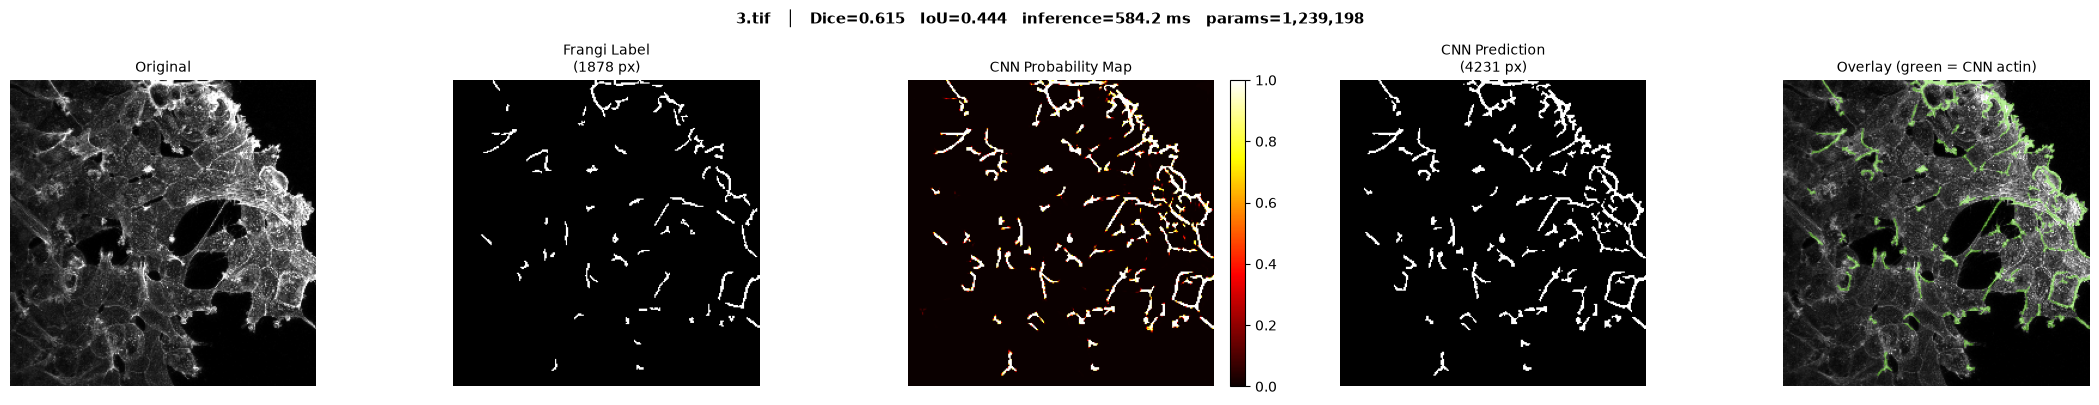

  3.tif  │  label=1878 px  pred=4231 px  Dice=0.615  IoU=0.444  584.2 ms



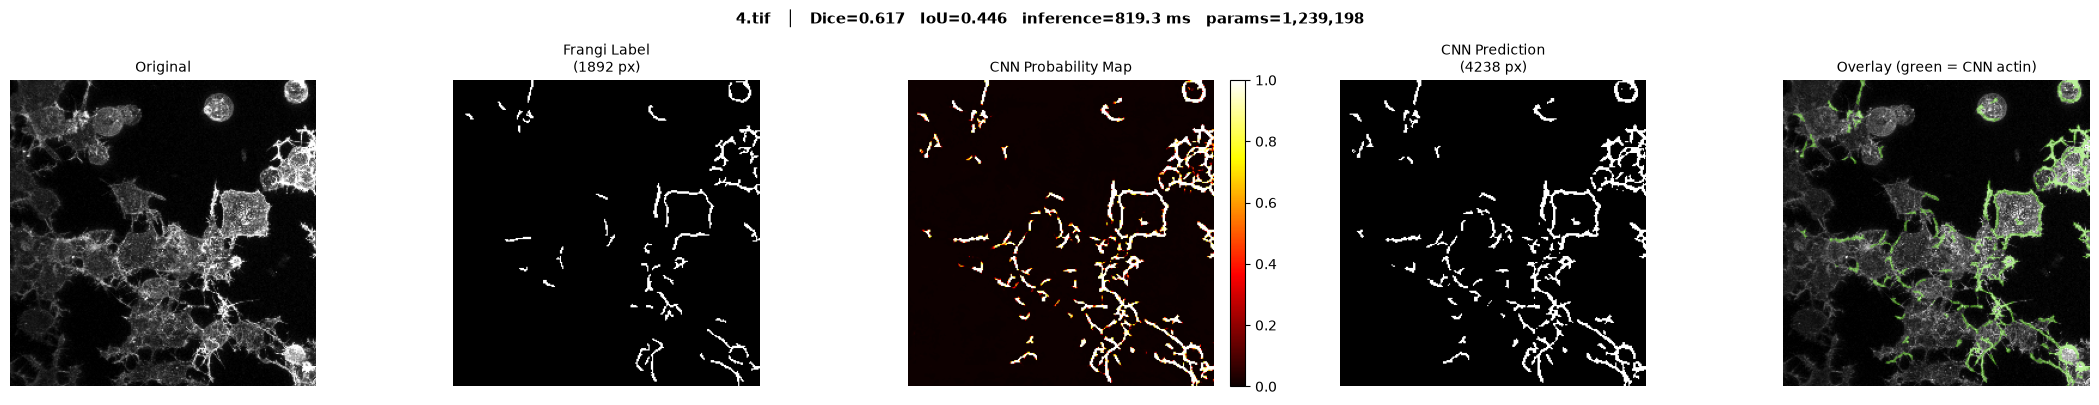

  4.tif  │  label=1892 px  pred=4238 px  Dice=0.617  IoU=0.446  819.3 ms



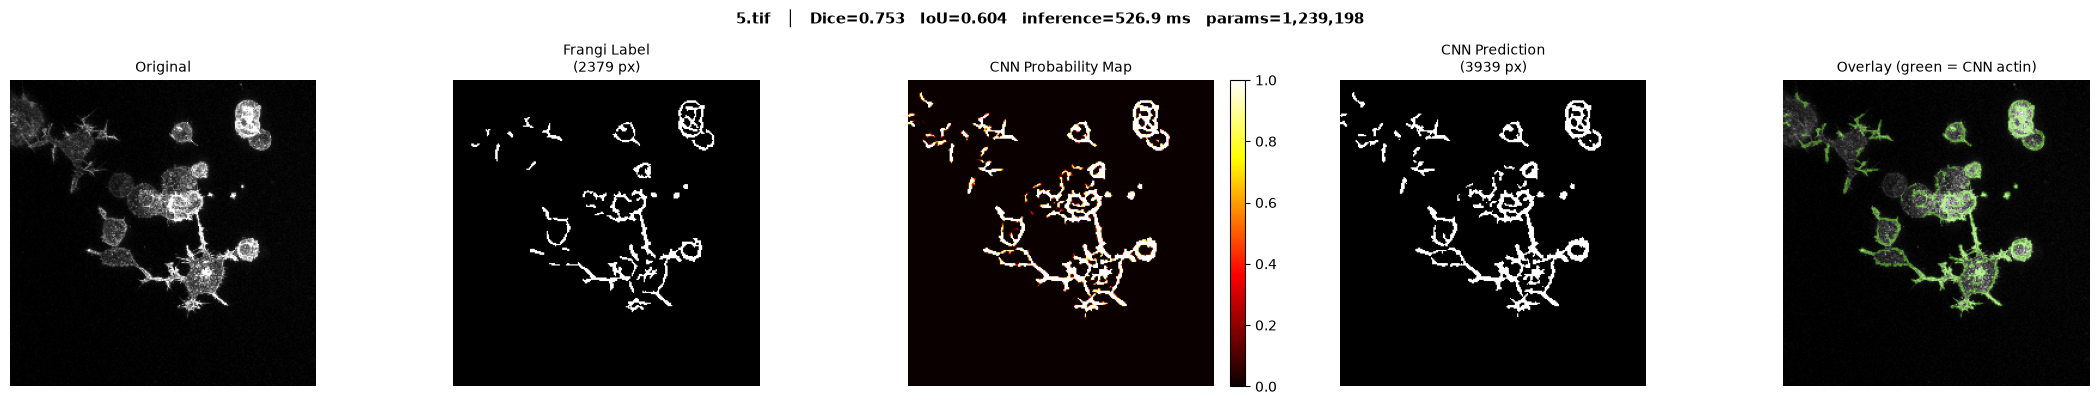

  5.tif  │  label=2379 px  pred=3939 px  Dice=0.753  IoU=0.604  526.9 ms



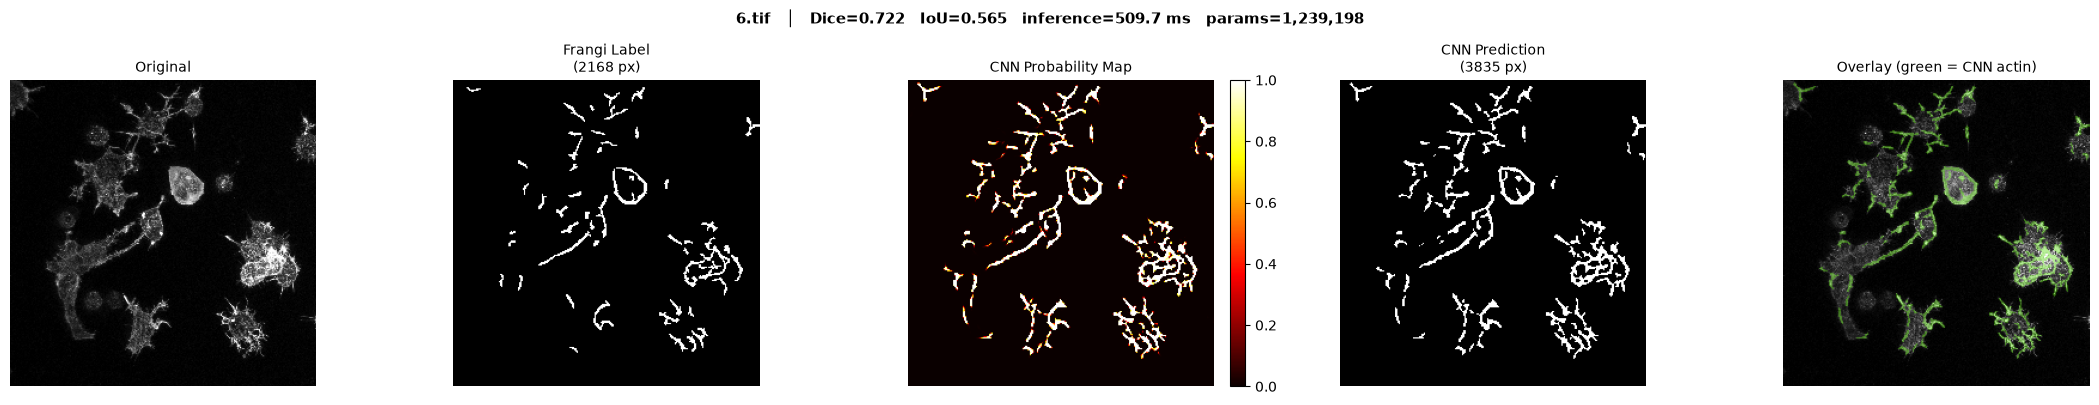

  6.tif  │  label=2168 px  pred=3835 px  Dice=0.722  IoU=0.565  509.7 ms



In [74]:
# ── 4. PREDICT + VISUALISE ALL IMAGES ─────────────────────────────────────
def overlay_mask(img_gray, mask, color_bgr=(0, 220, 80), alpha=0.4):
    """Return RGB image with mask overlaid in given colour."""
    bgr = cv2.cvtColor((img_gray * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    layer = bgr.copy()
    layer[mask.astype(bool)] = color_bgr
    blended = cv2.addWeighted(bgr, 1 - alpha, layer, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


image_paths = get_image_paths()
print(f'Found {len(image_paths)} image(s) — running inference...\n')

stats_rows = []

for path in image_paths:
    name = os.path.basename(path)

    # ── Load & resize ──────────────────────────────────────────────────
    raw = load_tif_image(path)
    img = cv2.resize(raw, config.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)

    # ── Classical Frangi label ─────────────────────────────────────────
    result       = preprocess_image(img)
    frangi_label = result['edge_mask']

    # ── CNN prediction ─────────────────────────────────────────────────
    prob_map, cnn_mask, elapsed = predict_single(img)

    # ── Dice vs classical label ────────────────────────────────────────
    eps  = 1e-6
    pred = cnn_mask.astype(bool).flatten()
    gt   = frangi_label.astype(bool).flatten()
    tp   = np.sum(pred & gt)
    fp   = np.sum(pred & ~gt)
    fn   = np.sum(~pred & gt)
    dice = (2*tp + eps) / (2*tp + fp + fn + eps)
    iou  = (tp + eps)   / (tp + fp + fn + eps)

    stats_rows.append({
        'image'        : name,
        'label_px'     : int(frangi_label.sum()),
        'pred_px'      : int(cnn_mask.sum()),
        'dice'         : round(dice, 4),
        'iou'          : round(iou,  4),
        'infer_ms'     : round(elapsed * 1000, 1),
    })

    # ── Figure ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(
        f'{name}   │   Dice={dice:.3f}   IoU={iou:.3f}   '
        f'inference={elapsed*1000:.1f} ms   params={n_params:,}',
        fontsize=11, fontweight='bold'
    )

    # Panel 1: original
    axes[0].imshow(img,          cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original', fontsize=10)

    # Panel 2: classical Frangi label
    axes[1].imshow(frangi_label, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(
        f'Frangi Label\n({int(frangi_label.sum())} px)', fontsize=10)

    # Panel 3: CNN probability map
    im = axes[2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[2].set_title('CNN Probability Map', fontsize=10)
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    # Panel 4: CNN binary prediction
    axes[3].imshow(cnn_mask,     cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(
        f'CNN Prediction\n({int(cnn_mask.sum())} px)', fontsize=10)

    # Panel 5: overlay on original
    axes[4].imshow(overlay_mask(img, cnn_mask))
    axes[4].set_title('Overlay (green = CNN actin)', fontsize=10)

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f'  {name}  │  label={int(frangi_label.sum())} px  '
          f'pred={int(cnn_mask.sum())} px  '
          f'Dice={dice:.3f}  IoU={iou:.3f}  {elapsed*1000:.1f} ms')
    print()

In [75]:
# ── 5. SUMMARY TABLE ──────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(stats_rows)
print(f'\n=== {MODEL_NAME} — Results Summary ===')
print(df.to_string(index=False))
print(f'\nMean Dice : {df["dice"].mean():.4f}')
print(f'Mean IoU  : {df["iou"].mean():.4f}')
print(f'Mean infer: {df["infer_ms"].mean():.1f} ms')
print(f'Params    : {n_params:,}')


=== resunetpp — Results Summary ===
image  label_px  pred_px   dice    iou  infer_ms
1.tif      1487     3208 0.6249 0.4545    1140.0
2.tif      1706     2132 0.8129 0.6848     516.5
3.tif      1878     4231 0.6145 0.4435     584.2
4.tif      1892     4238 0.6173 0.4464     819.3
5.tif      2379     3939 0.7531 0.6040     526.9
6.tif      2168     3835 0.7223 0.5653     509.7

Mean Dice : 0.6908
Mean IoU  : 0.5331
Mean infer: 682.8 ms
Params    : 1,239,198


Loaded unetpp (285,501 params)
Loaded attention_unet (2,000,733 params)
Loaded resunetpp (1,239,198 params)


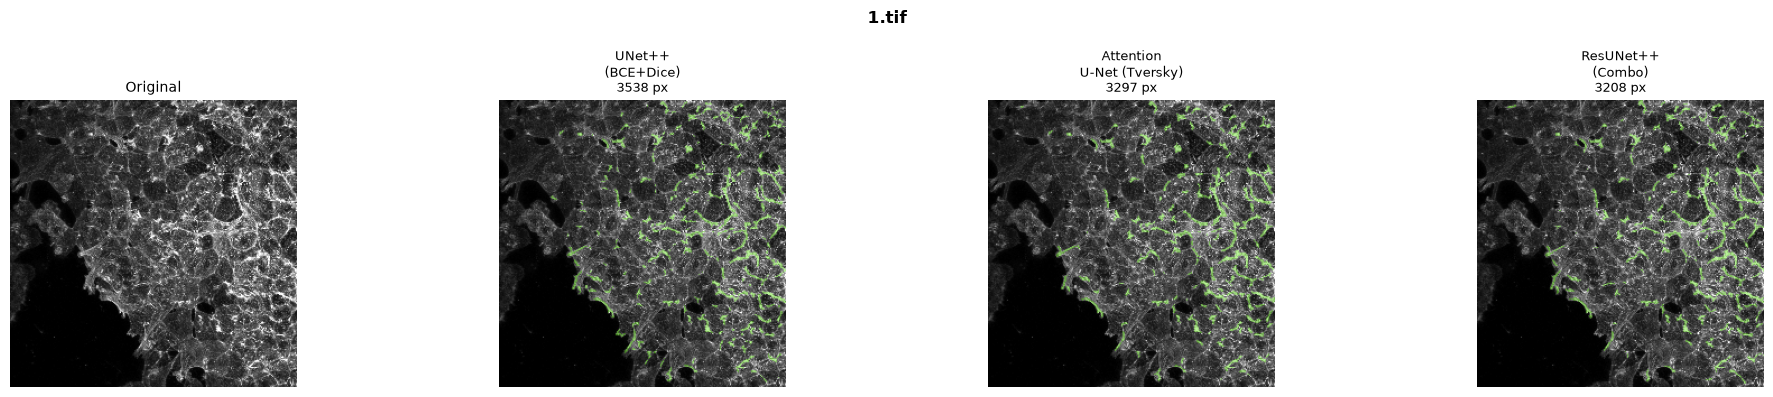

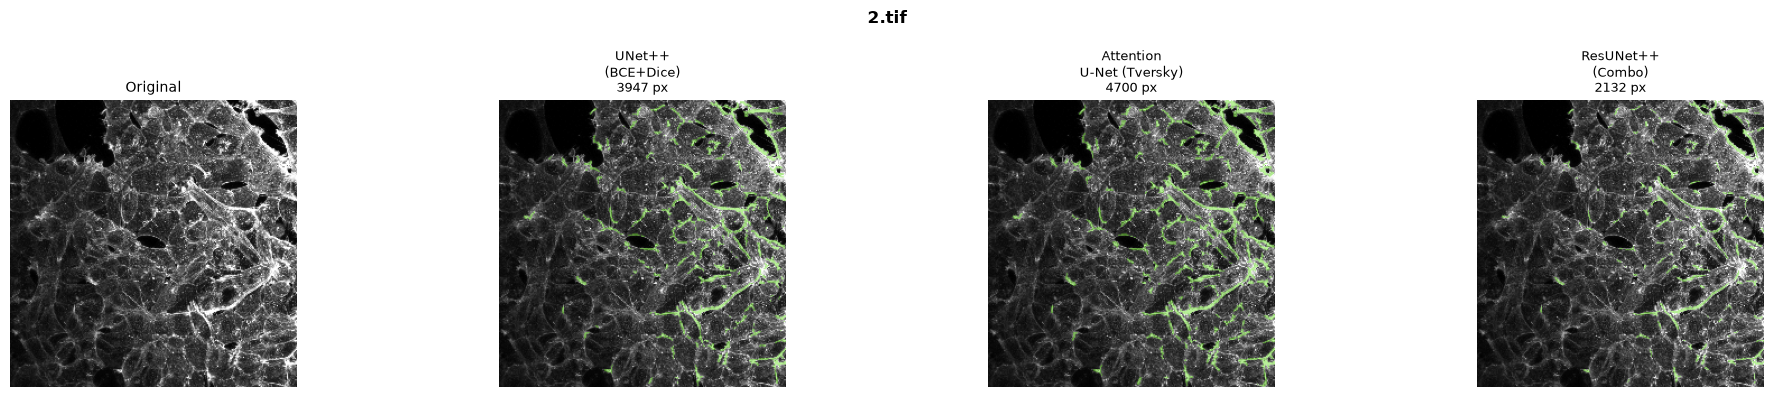

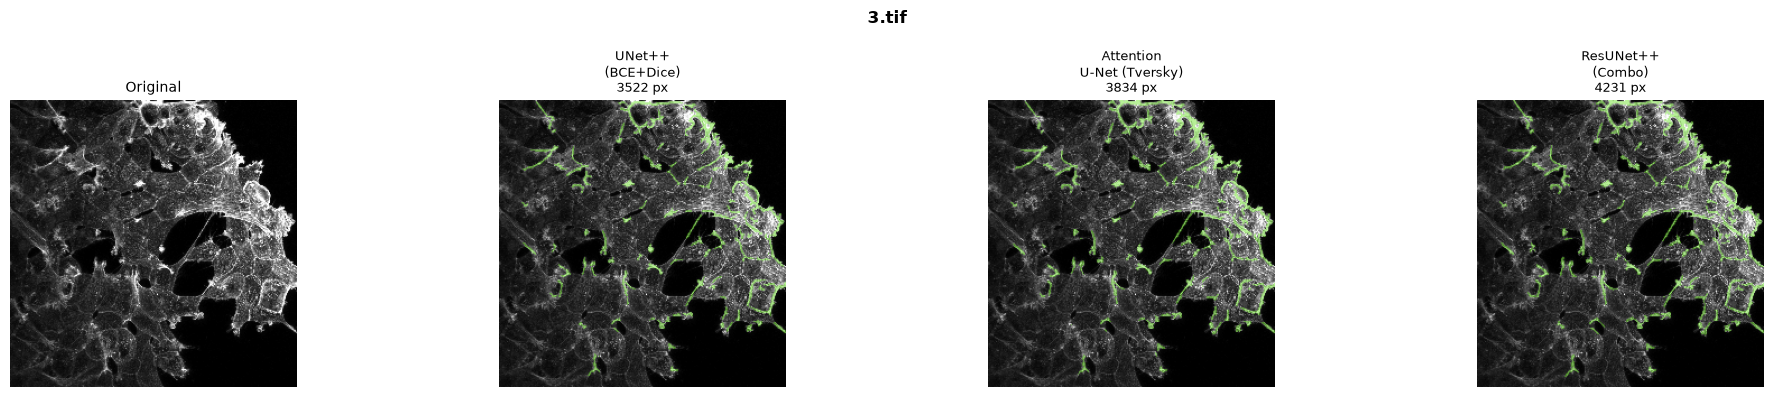

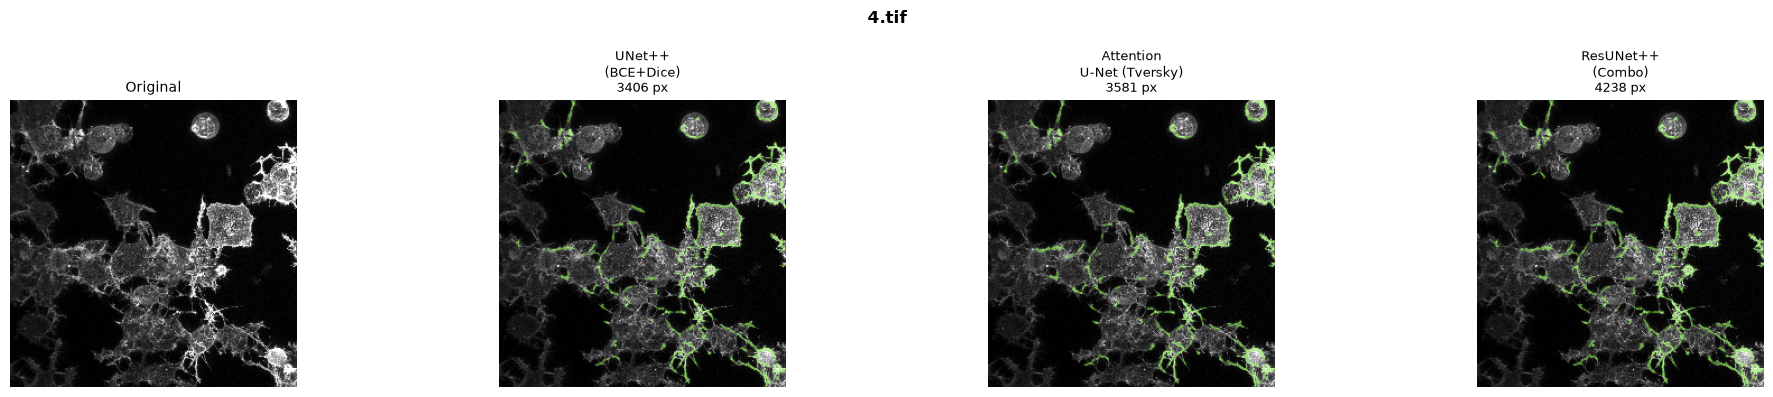

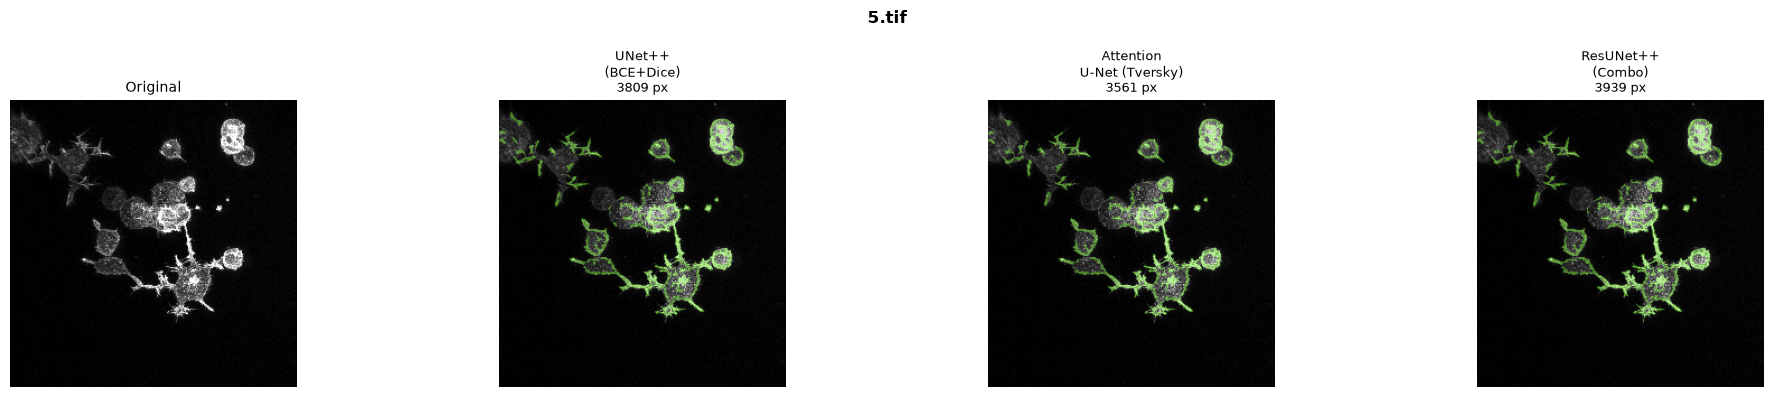

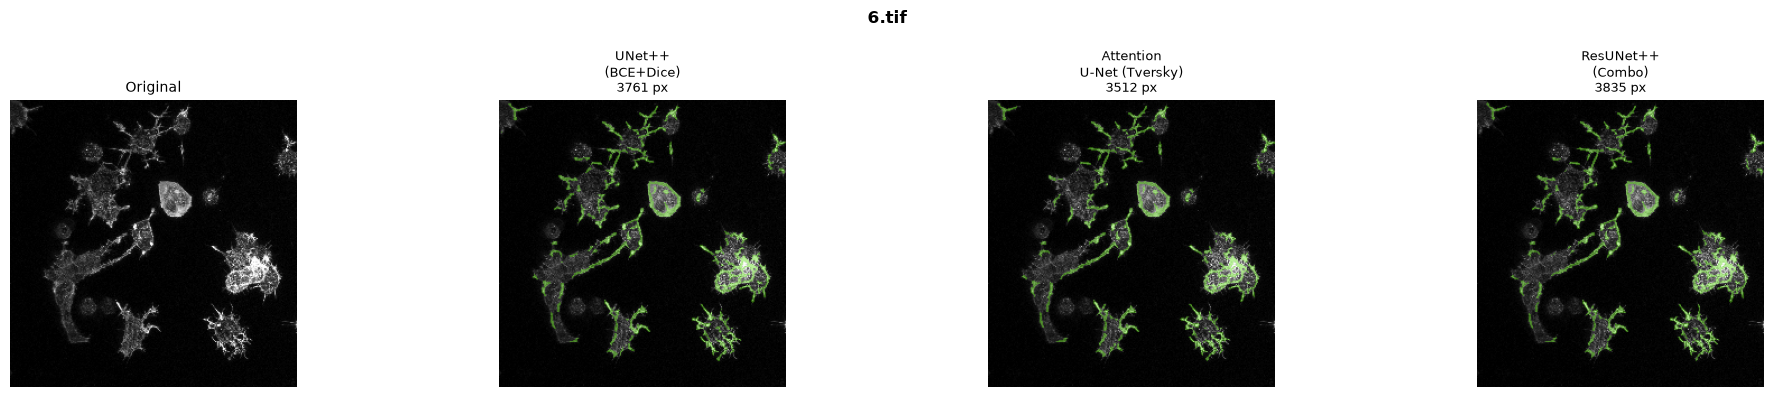

In [76]:
# ── 6. COMPARE ALL 3 MODELS SIDE BY SIDE (run after training all 3) ───────
# Shows Original | UNet++ pred | Attention pred | ResUNet++ pred for each image.
# Comment out or skip this cell if you have only trained one model so far.

all_models = {
    'unetpp'        : 'UNet++\n(BCE+Dice)',
    'attention_unet': 'Attention\nU-Net (Tversky)',
    'resunetpp'     : 'ResUNet++\n(Combo)',
}

# Load all available checkpoints
loaded = {}
for mname, label in all_models.items():
    ckpt = os.path.join(
        config.CHECKPOINT_DIR,
        config.MODEL_REGISTRY[mname]['checkpoint_name']
    )
    if os.path.exists(ckpt):
        loaded[mname] = (
            tf.keras.models.load_model(ckpt, compile=False),
            label
        )
        print(f'Loaded {mname} ({loaded[mname][0].count_params():,} params)')
    else:
        print(f'Skipping {mname} — checkpoint not found')

if len(loaded) < 2:
    print('Train at least 2 models to use this comparison cell.')
else:
    image_paths = get_image_paths()
    n_models = len(loaded)

    for path in image_paths:
        name = os.path.basename(path)
        raw  = load_tif_image(path)
        img  = cv2.resize(raw, config.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)

        fig, axes = plt.subplots(1, n_models + 1, figsize=(5 * (n_models + 1), 4))
        fig.suptitle(name, fontsize=12, fontweight='bold')

        axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[0].set_title('Original', fontsize=10)
        axes[0].axis('off')

        for col, (mname, (m, label)) in enumerate(loaded.items(), start=1):
            tensor = img[np.newaxis, ..., np.newaxis].astype(np.float32)
            outs   = m(tensor, training=False)
            logits = outs[-1] if isinstance(outs, (list, tuple)) else outs
            prob   = tf.sigmoid(logits).numpy().squeeze()
            pred   = (prob >= THRESHOLD).astype(np.uint8)

            axes[col].imshow(overlay_mask(img, pred))
            axes[col].set_title(f'{label}\n{int(pred.sum())} px', fontsize=9)
            axes[col].axis('off')

        plt.tight_layout()
        plt.show()

In [77]:
# ── 7. SAVE ALL PREDICTED MASKS AS PNG ────────────────────────────────────
save_dir = os.path.join(config.OUTPUT_DIR, f'masks_pred_{MODEL_NAME}')
os.makedirs(save_dir, exist_ok=True)

for path in get_image_paths():
    name = os.path.basename(path)
    raw  = load_tif_image(path)
    img  = cv2.resize(raw, config.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)

    tensor = img[np.newaxis, ..., np.newaxis].astype(np.float32)
    outs   = model(tensor, training=False)
    logits = outs[-1] if isinstance(outs, (list, tuple)) else outs
    pred   = (tf.sigmoid(logits).numpy().squeeze() >= THRESHOLD).astype(np.uint8)

    out_path = os.path.join(save_dir, os.path.splitext(name)[0] + '_pred.png')
    cv2.imwrite(out_path, pred * 255)
    print(f'Saved: {out_path}')

print(f'\nAll masks saved to: {save_dir}')

Saved: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp/1_pred.png
Saved: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp/2_pred.png
Saved: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp/3_pred.png
Saved: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp/4_pred.png
Saved: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp/5_pred.png
Saved: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp/6_pred.png

All masks saved to: /home/harsh/CV_work/group_8/outputs/masks_pred_resunetpp
